In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [2]:
MASTER = Path(
    "/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/master_feature_engineered.parquet"
)

master = pd.read_parquet(MASTER)

print(master.shape)

(35072, 122)


In [3]:
TARGET = "is_correct"

DROP_COLUMNS = [

    "response_id",
    "session_id",

    "learning_objective",
    "learning_objective_id",

    "transcript",
    "student_text",
    "tutor_text",
    "background_text",

    TARGET,
]

X = master.drop(columns=DROP_COLUMNS)

y = master[TARGET].astype(int)

In [4]:
categorical_cols = X.select_dtypes(include="object").columns

for col in categorical_cols:
    X[col] = X[col].astype("category").cat.codes

In [5]:
kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

oof_pred = np.zeros(len(X))

scores = []

feature_importance = np.zeros(X.shape[1])

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), 1):

    print("="*60)
    print(f"Fold {fold}")
    print("="*60)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = XGBClassifier(

        n_estimators=3000,

        learning_rate=0.03,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        min_child_weight=5,

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        early_stopping_rounds=300,
    )

    model.fit(

        X_train,
        y_train,

        eval_set=[(X_valid, y_valid)],

        verbose=200,
    )

    pred = model.predict_proba(X_valid)[:, 1]

    oof_pred[valid_idx] = pred

    loss = log_loss(y_valid, pred)

    scores.append(loss)

    feature_importance += model.feature_importances_

    print(f"\nFold {fold} LogLoss : {loss:.6f}")

Fold 1
[0]	validation_0-logloss:0.60643
[200]	validation_0-logloss:0.54467
[400]	validation_0-logloss:0.54059
[600]	validation_0-logloss:0.53974
[800]	validation_0-logloss:0.54034
[886]	validation_0-logloss:0.54111

Fold 1 LogLoss : 0.539665
Fold 2
[0]	validation_0-logloss:0.60651
[200]	validation_0-logloss:0.55099
[400]	validation_0-logloss:0.54851
[600]	validation_0-logloss:0.54811
[800]	validation_0-logloss:0.55054
[838]	validation_0-logloss:0.55112

Fold 2 LogLoss : 0.547780
Fold 3
[0]	validation_0-logloss:0.60673
[200]	validation_0-logloss:0.54796
[400]	validation_0-logloss:0.54613
[600]	validation_0-logloss:0.54673
[769]	validation_0-logloss:0.54752

Fold 3 LogLoss : 0.545964
Fold 4
[0]	validation_0-logloss:0.60664
[200]	validation_0-logloss:0.54799
[400]	validation_0-logloss:0.54630
[600]	validation_0-logloss:0.54640
[793]	validation_0-logloss:0.54800

Fold 4 LogLoss : 0.545772
Fold 5
[0]	validation_0-logloss:0.60677
[200]	validation_0-logloss:0.55049
[400]	validation_0-logloss:

In [6]:
print()

print("="*60)

print("Fold LogLoss")

print(scores)

print()

print("Mean LogLoss :", np.mean(scores))

print("Std LogLoss  :", np.std(scores))

print("="*60)

overall = log_loss(y, oof_pred)

print()

print("="*60)

print(f"Overall OOF LogLoss : {overall:.6f}")

print("="*60)


Fold LogLoss
[0.5396647594303939, 0.5477801374950741, 0.5459636597875043, 0.5457718388014757, 0.5459786721399431]

Mean LogLoss : 0.5450318135308783
Std LogLoss  : 0.002781045501331109

Overall OOF LogLoss : 0.545032


In [7]:
feature_importance /= 5

importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": feature_importance
    })
    .sort_values("importance", ascending=False)
)

display(importance.head(30))

,feature,importance
8,obj_has_decimal,0.036572
23,obj_has_percentage,0.022846
9,obj_has_money,0.022821
17,obj_has_multiply,0.019627
4,objective_char_count,0.019247
6,objective_avg_word_length,0.018968
5,objective_word_count,0.017564
0,objective_frequency,0.016929
25,obj_has_area,0.016148
3,objective_frequency_percentile,0.015607


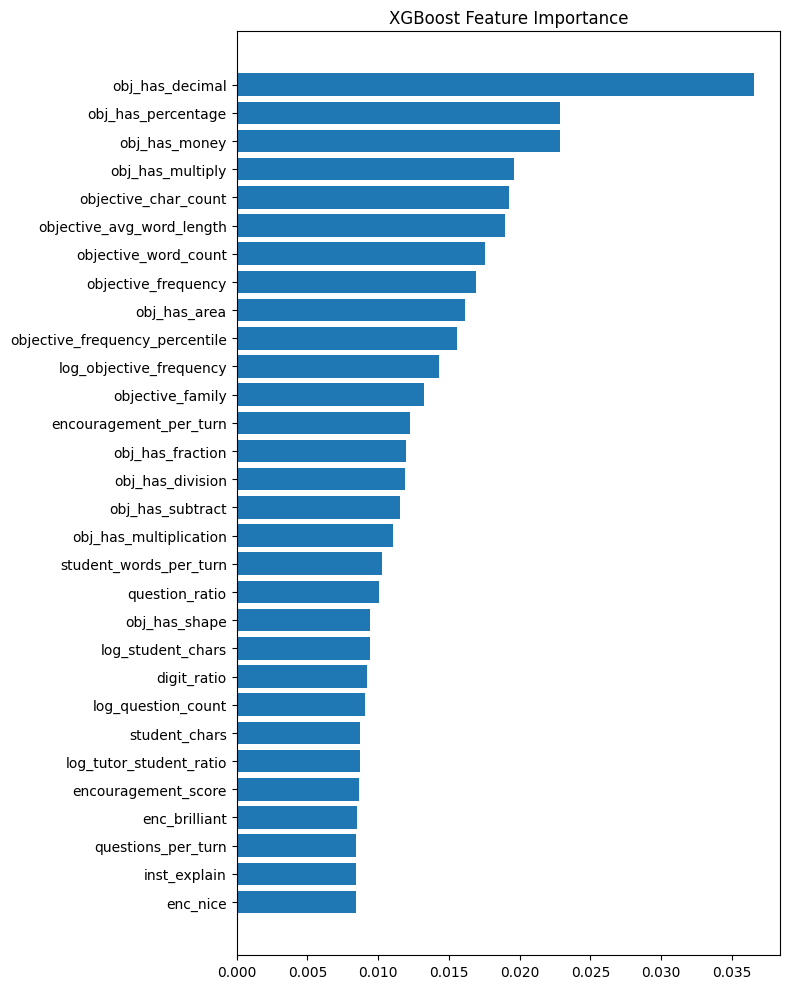

In [8]:
plt.figure(figsize=(8,10))

plt.barh(
    importance.head(30)["feature"][::-1],
    importance.head(30)["importance"][::-1]
)

plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.show()